# AI Generated image detection

Dataset source: Krizhevsky, A., & Hinton, G. (2009). Learning multiple layers of features from tiny images.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/febagnatori/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3


In [2]:
import os

splits = ['train', 'test']
classes = ['REAL', 'FAKE']

total = 0
print(f"{'Split':<10} {'Class':<10} {'Count':>8}")
print("-" * 30)
for split in splits:
    for cls in classes:
        folder = os.path.join(path, split, cls)
        count = len(os.listdir(folder))
        total += count
        print(f"{split:<10} {cls:<10} {count:>8,}")
    print()

print(f"{'TOTAL':<10} {'':<10} {total:>8,}")

Split      Class         Count
------------------------------
train      REAL         50,000
train      FAKE         50,000

test       REAL         10,000
test       FAKE         10,000

TOTAL                  120,000


In [3]:
import glob
from sklearn.model_selection import train_test_split

all_paths, all_labels = [], []

# Labels: 0 = Real, 1 = Fake.
for cls, label in [('REAL', 0), ('FAKE', 1)]:
    for split in ['train', 'test']:
        folder = os.path.join(path, split, cls)
        files = glob.glob(os.path.join(folder, '*'))
        all_paths.extend(files)
        all_labels.extend([label] * len(files))

# 80 / 10 / 10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train):>7,}  ({len(X_train)/len(all_paths)*100:.1f}%)")
print(f"Val   : {len(X_val):>7,}  ({len(X_val)/len(all_paths)*100:.1f}%)")
print(f"Test  : {len(X_test):>7,}  ({len(X_test)/len(all_paths)*100:.1f}%)")
print(f"Total : {len(all_paths):>7,}")

Train :  96,000  (80.0%)
Val   :  12,000  (10.0%)
Test  :  12,000  (10.0%)
Total : 120,000


In [4]:
import tensorflow as tf

BATCH_SIZE = 64
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 127.5 - 1.0  # normalize to [-1, 1]
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.pad_to_bounding_box(image, 4, 4, IMG_SIZE[0] + 8, IMG_SIZE[1] + 8)
    image = tf.image.random_crop(image, size=[IMG_SIZE[0], IMG_SIZE[1], 3])
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=2048)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Train batches : 1500
Val batches   : 188
Test batches  : 188


2026-06-17 18:55:53.791093: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-17 18:55:53.791122: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-17 18:55:53.791125: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-06-17 18:55:53.791137: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-17 18:55:53.791146: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base during initial training

inputs = base_model.input
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary: REAL vs FAKE

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('./models/best_model.keras', monitor='val_accuracy', save_best_only=True),
]

# Phase 1: train head only (base frozen)
print("=== Phase 1: Training head (base frozen) ===")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
)

# Phase 2: fine-tune top layers of base model
print("\n=== Phase 2: Fine-tuning top layers ===")
base_model.trainable = True
for layer in base_model.layers[:-30]:  # keep bottom layers frozen
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much lower lr for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
)

=== Phase 1: Training head (base frozen) ===
Epoch 1/10


2026-06-17 18:55:55.859665: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 225s 147ms/step - accuracy: 0.5075 - loss: 1.0084 - val_accuracy: 0.5250 - val_loss: 0.6888 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 214s 143ms/step - accuracy: 0.5215 - loss: 0.6980 - val_accuracy: 0.5408 - val_loss: 0.6777 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 214s 143ms/step - accuracy: 0.5627 - loss: 0.6969 - val_accuracy: 0.5957 - val_loss: 0.6612 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 217s 145ms/step - accuracy: 0.5868 - loss: 0.7032 - val_accuracy: 0.5091 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 215s 144ms/step - accuracy: 0.5935 - loss: 0.7182 - val_accuracy: 0.5049 - val_loss: 0.7199 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 215s 143ms/step - accuracy: 0.6023 - loss: 0.7314 - val_accuracy: 0.5554 - val_loss: 0.6787 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 216s 144ms/step - acc

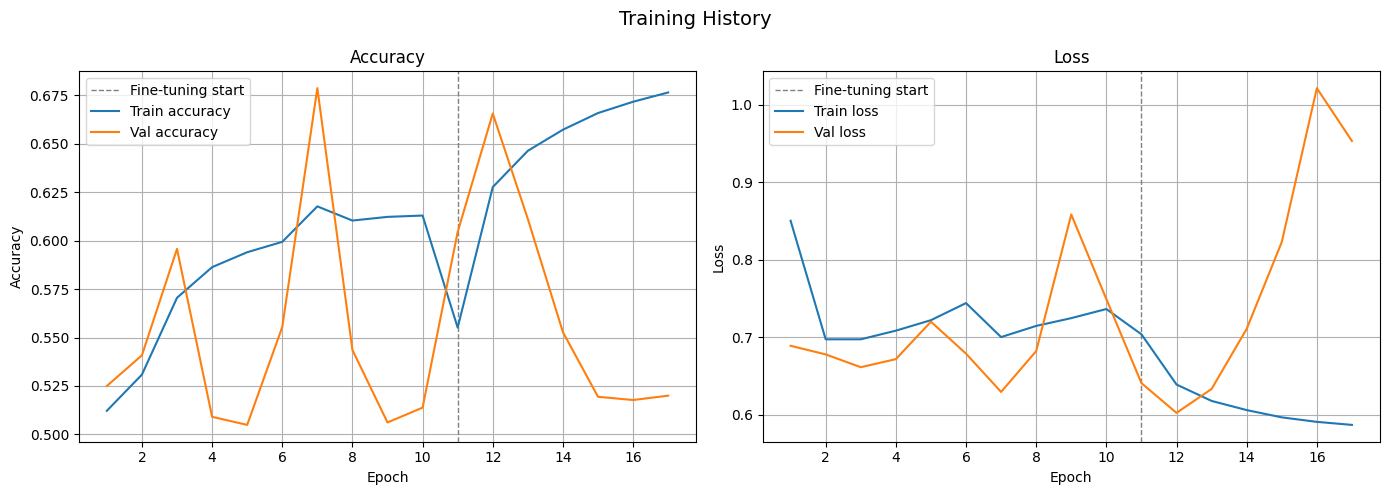

In [7]:
import matplotlib.pyplot as plt

def plot_history(h1, h2):
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    epochs  = range(1, len(acc) + 1)
    phase2_start = len(h1.history['accuracy']) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax in (ax1, ax2):
        ax.axvline(phase2_start, color='gray', linestyle='--', linewidth=1, label='Fine-tuning start')

    ax1.plot(epochs, acc,     label='Train accuracy')
    ax1.plot(epochs, val_acc, label='Val accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, loss,     label='Train loss')
    ax2.plot(epochs, val_loss, label='Val loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle('Training History', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history_phase1, history_phase2)

188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - accuracy: 0.6676 - loss: 0.5994

Test Loss     : 0.6045
Test Accuracy : 0.6617
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step

Classification Report:
              precision    recall  f1-score   support

        REAL       0.61      0.93      0.73      6000
        FAKE       0.85      0.40      0.54      6000

    accuracy                           0.66     12000
   macro avg       0.73      0.66      0.64     12000
weighted avg       0.73      0.66      0.64     12000



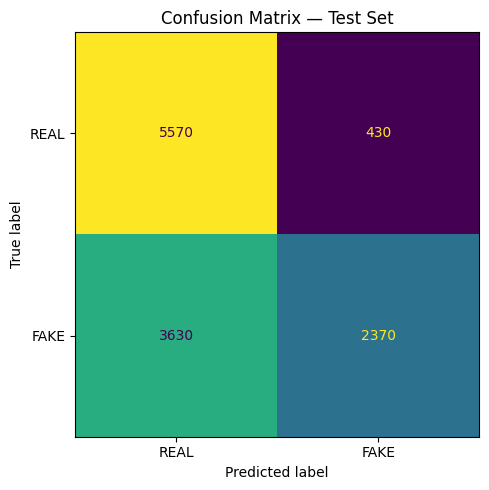

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate loss and accuracy
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Predictions for detailed metrics
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['REAL', 'FAKE']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

Model loaded successfully.


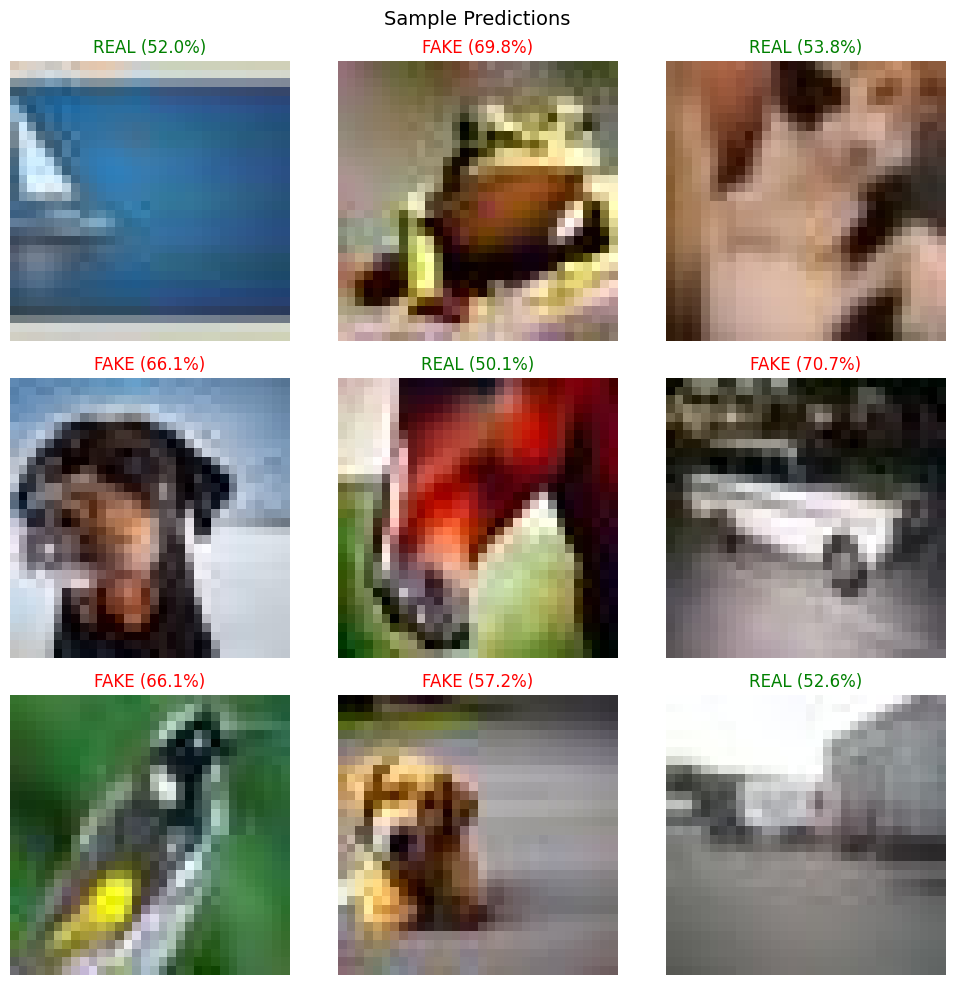

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# best_model.keras was already saved by ModelCheckpoint during training
# Load it back for inference
inference_model = tf.keras.models.load_model('./models/best_model.keras')
print("Model loaded successfully.")

def predict_image(model, image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(IMG_SIZE)
    x = np.array(image, dtype=np.float32) / 127.5 - 1.0
    x = np.expand_dims(x, axis=0)  # (1, 224, 224, 3)

    prob = model.predict(x, verbose=0)[0][0]
    label = 'FAKE' if prob >= 0.5 else 'REAL'
    confidence = prob if prob >= 0.5 else 1 - prob
    return label, confidence

# Run inference on a few sample images from the test set
samples = X_test[:9]
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, img_path in zip(axes.flatten(), samples):
    label, confidence = predict_image(inference_model, img_path)
    image = Image.open(img_path).convert('RGB')
    ax.imshow(image)
    ax.set_title(f"{label} ({confidence:.1%})", color='red' if label == 'FAKE' else 'green')
    ax.axis('off')

plt.suptitle('Sample Predictions', fontsize=14)
plt.tight_layout()
plt.show()

Using layer: top_activation


/opt/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


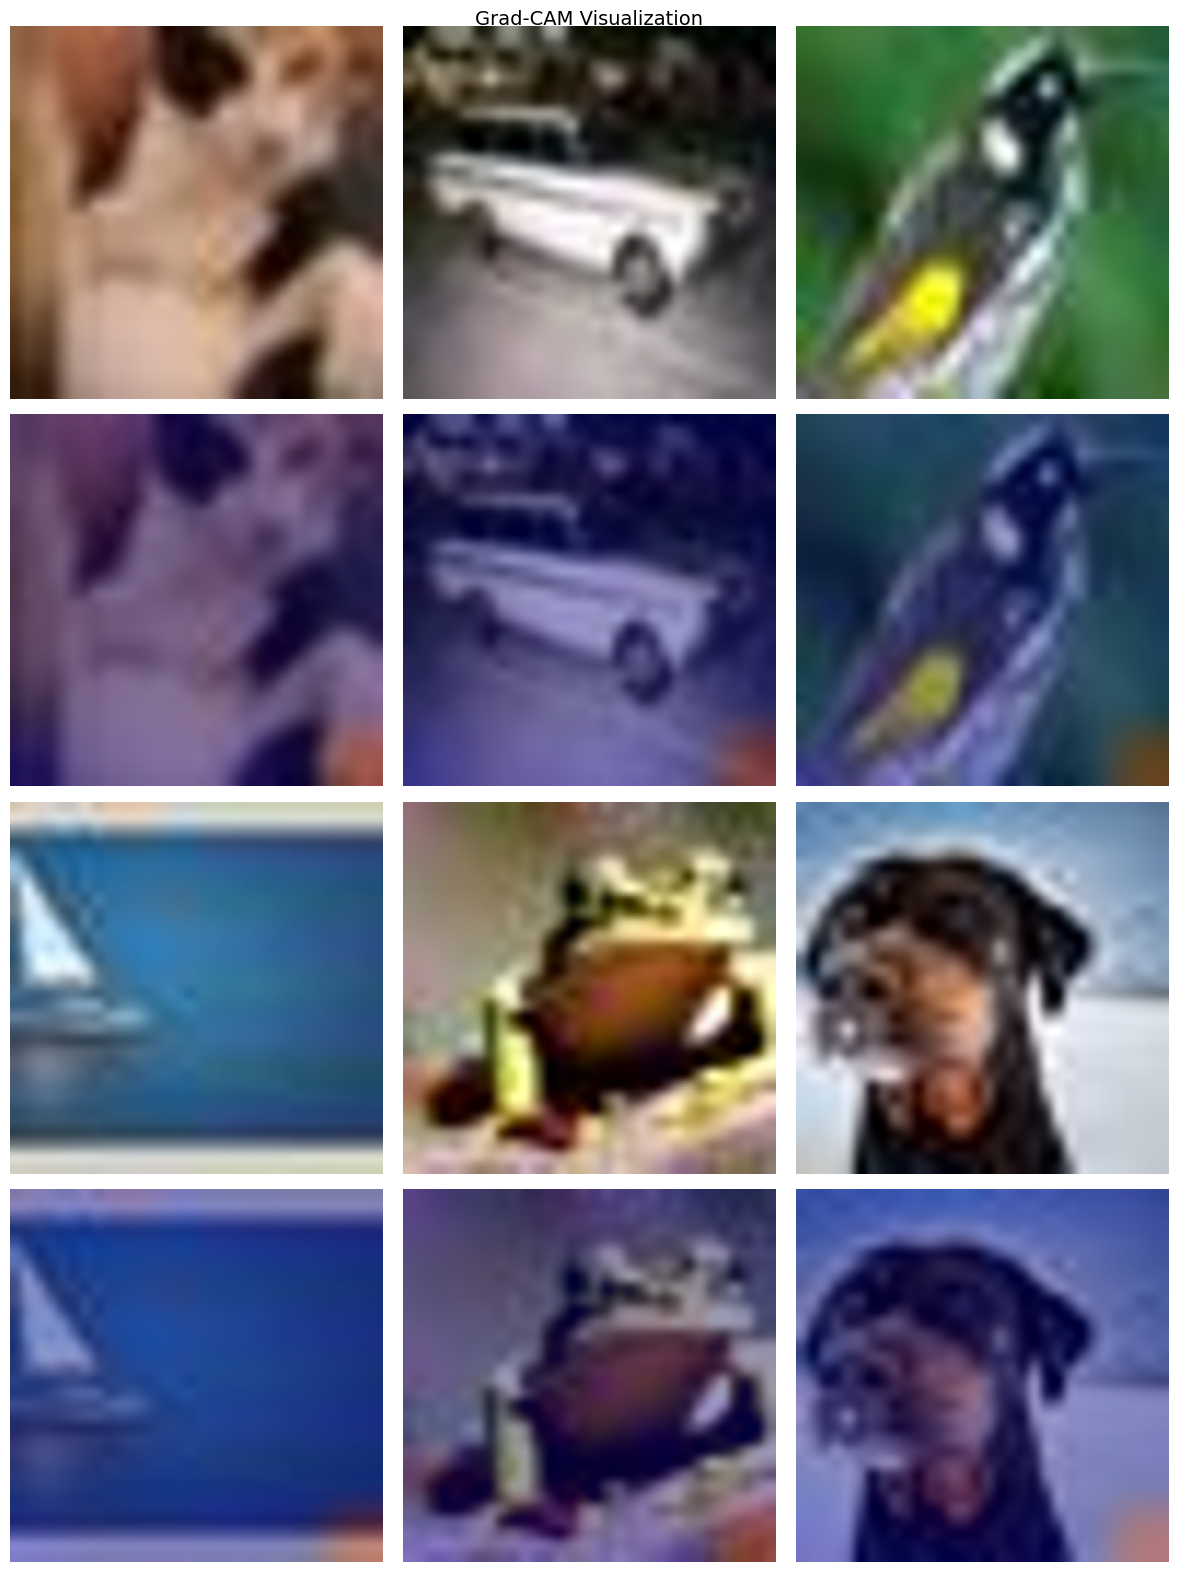

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

# Find the last convolutional layer with spatial dimensions
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Activation)):
            if len(layer.output.shape) == 4:  # (batch, h, w, c)
                return layer.name
    raise ValueError("No suitable layer found")

last_conv_layer_name = get_last_conv_layer_name(inference_model)
print(f"Using layer: {last_conv_layer_name}")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]  # binary output

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE))
    colored = np.uint8(cm.jet(np.uint8(255 * heatmap))[:, :, :3] * 255)
    colored = np.array(Image.fromarray(colored).resize(IMG_SIZE))
    return img, np.uint8(img * (1 - alpha) + colored * alpha)

def preprocess(img_path):
    img = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE), dtype=np.float32)
    return np.expand_dims(img / 127.5 - 1.0, axis=0)

# 3 samples per class
real_paths = [p for p, l in zip(X_test, y_test) if l == 0][:3]
fake_paths = [p for p, l in zip(X_test, y_test) if l == 1][:3]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
row_labels = ['REAL — Original', 'REAL — Grad-CAM', 'FAKE — Original', 'FAKE — Grad-CAM']
row_colors = ['green', 'green', 'red', 'red']

for col, img_path in enumerate(real_paths):
    heatmap = make_gradcam_heatmap(preprocess(img_path), inference_model, last_conv_layer_name)
    img, overlay = overlay_gradcam(img_path, heatmap)
    axes[0, col].imshow(img)
    axes[1, col].imshow(overlay)

for col, img_path in enumerate(fake_paths):
    heatmap = make_gradcam_heatmap(preprocess(img_path), inference_model, last_conv_layer_name)
    img, overlay = overlay_gradcam(img_path, heatmap)
    axes[2, col].imshow(img)
    axes[3, col].imshow(overlay)

for row, (label, color) in enumerate(zip(row_labels, row_colors)):
    axes[row, 0].set_ylabel(label, color=color, fontsize=11, fontweight='bold')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Grad-CAM Visualization', fontsize=14)
plt.tight_layout()
plt.show()

False Positives (REAL → FAKE) : 430
False Negatives (FAKE → REAL) : 3630


/var/folders/wd/br8r9td54_701m8zzx7ff2nr0000gn/T/ipykernel_39383/2168552942.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  conf = float(y_pred_probs[idx])
/var/folders/wd/br8r9td54_701m8zzx7ff2nr0000gn/T/ipykernel_39383/2168552942.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  conf = 1 - float(y_pred_probs[idx])


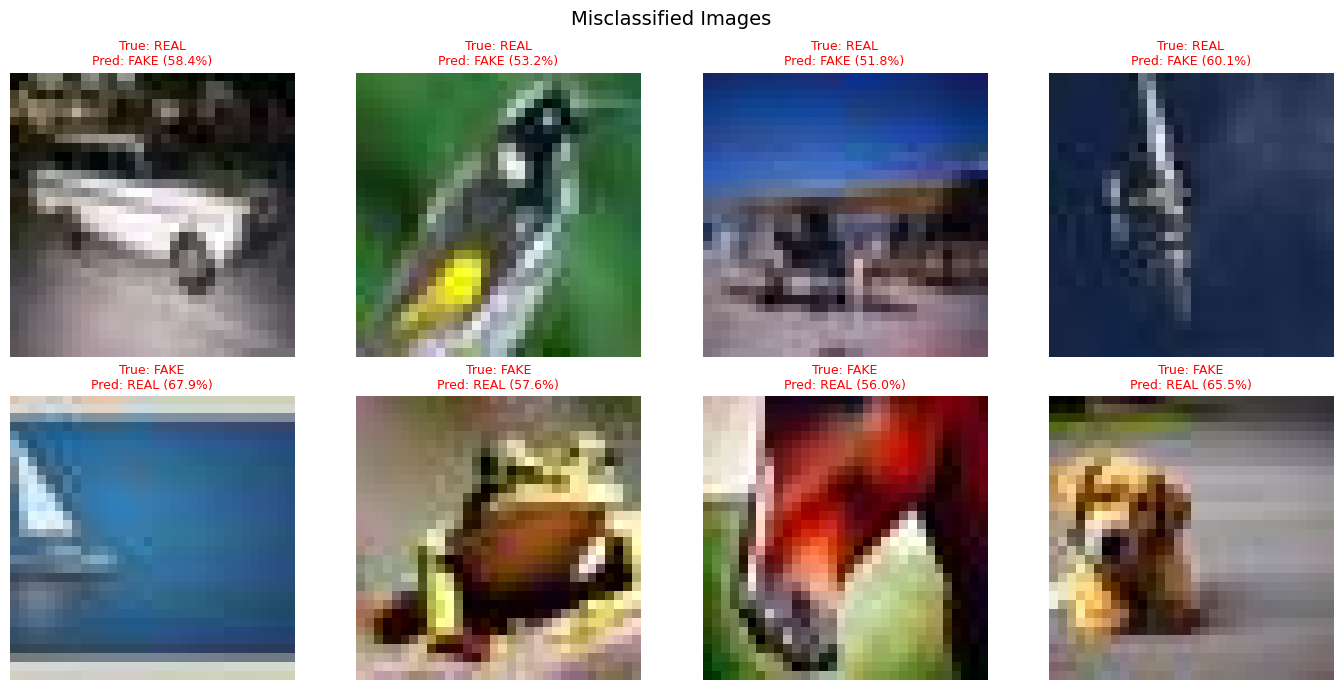

In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

y_test_arr = np.array(y_test)

# False Positives: REAL predicted as FAKE
fp_indices = np.where((y_test_arr == 0) & (y_pred == 1))[0]
# False Negatives: FAKE predicted as REAL
fn_indices = np.where((y_test_arr == 1) & (y_pred == 0))[0]

print(f"False Positives (REAL → FAKE) : {len(fp_indices)}")
print(f"False Negatives (FAKE → REAL) : {len(fn_indices)}")

n_cols = 4
fp_sample = fp_indices[:n_cols]
fn_sample = fn_indices[:n_cols]

fig, axes = plt.subplots(2, n_cols, figsize=(14, 7))

for col, idx in enumerate(fp_sample):
    img = Image.open(X_test[idx]).convert('RGB')
    conf = float(y_pred_probs[idx])
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"True: REAL\nPred: FAKE ({conf:.1%})", color='red', fontsize=9)
    axes[0, col].axis('off')

for col, idx in enumerate(fn_sample):
    img = Image.open(X_test[idx]).convert('RGB')
    conf = 1 - float(y_pred_probs[idx])
    axes[1, col].imshow(img)
    axes[1, col].set_title(f"True: FAKE\nPred: REAL ({conf:.1%})", color='red', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('False Positives\n(REAL → FAKE)', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('False Negatives\n(FAKE → REAL)', fontsize=10, fontweight='bold')

plt.suptitle('Misclassified Images', fontsize=14)
plt.tight_layout()
plt.show()

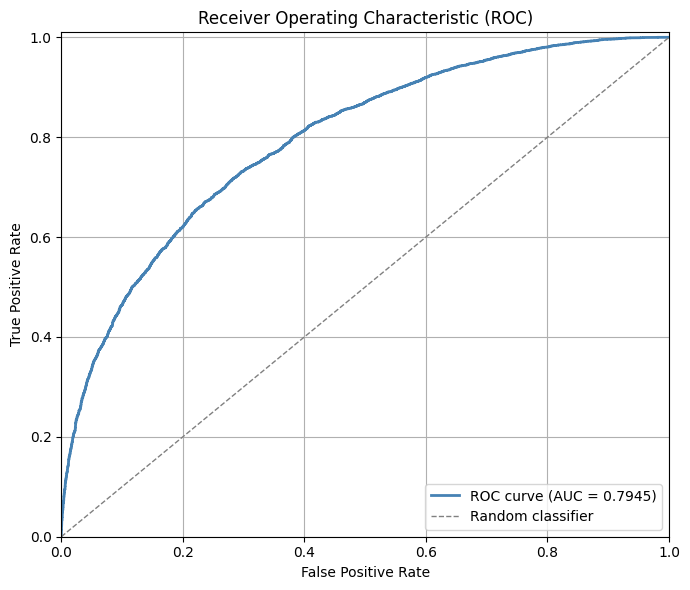

AUC: 0.7945


In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")